# Distance pipeline notebook

This notebook mirrors the refactored pipeline while keeping the intermediate artefacts easy to inspect.

In [1]:
from pathlib import Path
import sys

import geopandas as gpd
import pandas as pd

In [2]:
PROJECT_ROOT = Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT

WindowsPath('c:/local/GIT/Public-Infrastructure-Service-Access/Research-Sandbox/general_distances_per_country')

In [3]:
from distance_pipeline.cache import CacheManager
from distance_pipeline.candidate_builder import build_candidate_sites
from distance_pipeline.config_loader import load_cfg
from distance_pipeline.distance_matrix import compute_distances
from distance_pipeline.facilities import load_health_facilities
from distance_pipeline.io import download_file
from distance_pipeline.network import build_pandana_network, load_osm_network
from distance_pipeline.pipeline_support import build_context_map_path, build_map_facilities, resolve_candidate_grid_spacing
from distance_pipeline.population import worldpop_to_points
from distance_pipeline.settings import PipelineSettings
from distance_pipeline.snapping import snap_points_to_nodes
from distance_pipeline.source_tables import combine_existing_and_candidate_sources, ensure_id_column, ensure_id_index_matches
from distance_pipeline.viz import classify_roads, plot_context_map, to_point_geometries

In [4]:
def format_shape(df: pd.DataFrame) -> str:
    '''Return shape formatted with thousands separators.'''
    rows, cols = df.shape
    return f'{rows:,} x {cols:,}'

In [5]:
COUNTRY_CODE = 'timor-leste'

settings = PipelineSettings(
    population_threshold=1.0,
    sample_fraction=1.0,
    max_points=None,
    max_total_dist=None,
    candidate_grid_spacing_m=None,  # use cfg default
    candidate_max_snap_dist_m=None,  # use cfg default
    force_recompute=False,
    verbose=True,
    save_context_map=True,
    show_context_map=True,
    context_map_path=None,
    context_map_dpi=300,
)

cfg = load_cfg(COUNTRY_CODE)

cache = CacheManager(
    cfg=cfg,
    force_recompute=settings.force_recompute,
    verbose=settings.verbose,
)

print(cfg)
print(f'Candidate grid spacing from cfg: {cfg.candidate_grid_spacing_m}')
print(f'Candidate max snap distance from cfg: {cfg.candidate_max_snap_dist_m}')

CountryConfig(iso3='TLS', iso2='TL', country_name='Timor Leste', country_slug='east-timor', projected_epsg=32751, base_root=WindowsPath('C:/local/Download_Depot'), distance_threshold_km=300.0, geofabrik_region='asia', worldpop_year=2020, worldpop_suffix='ppp', worldpop_adjustment='UNadj', worldpop_filename='tls_ppp_2020.tif', pbf_filename=None, plot_title_suffix='roads by class, population points, and health facilities', boundary_source='natural_earth', candidate_grid_spacing_m=5000.0, candidate_exclude_water=True, candidate_include_boundary=True, candidate_max_snap_dist_m=5000.0)
Candidate grid spacing from cfg: 5000.0
Candidate max snap distance from cfg: 5000.0


In [6]:
print(f'Country: {cfg.COUNTRY_NAME}')
print(f'Base directory: {cfg.BASE_DIR}')
print(f'PBF path: {cfg.PBF_PATH}')
print(f'WorldPop path: {cfg.WORLDPOP_PATH}')
print(f'Distance threshold km: {cfg.DISTANCE_THRESHOLD_KM}')
print(f'Projected EPSG: {cfg.PROJECTED_EPSG}')
print()
print(settings)

Country: Timor Leste
Base directory: C:\local\Download_Depot\east-timor_data
PBF path: C:\local\Download_Depot\east-timor_data\east-timor-latest.osm.pbf
WorldPop path: C:\local\Download_Depot\east-timor_data\tls_ppp_2020.tif
Distance threshold km: 300.0
Projected EPSG: 32751

PipelineSettings(population_threshold=1.0, sample_fraction=1.0, max_points=None, max_total_dist=None, candidate_grid_spacing_m=None, candidate_max_snap_dist_m=None, force_recompute=False, verbose=True, save_context_map=True, show_context_map=True, context_map_path=None, context_map_dpi=300)


In [7]:
cfg.BASE_DIR.mkdir(parents=True, exist_ok=True)

download_file(cfg.PBF_URL, cfg.PBF_PATH, overwrite=False, verbose=settings.verbose)
download_file(cfg.WORLDPOP_URL, cfg.WORLDPOP_PATH, overwrite=False, verbose=settings.verbose)

Using existing file: C:\local\Download_Depot\east-timor_data\east-timor-latest.osm.pbf
Using existing file: C:\local\Download_Depot\east-timor_data\tls_ppp_2020.tif


WindowsPath('C:/local/Download_Depot/east-timor_data/tls_ppp_2020.tif')

In [8]:
nodes, edges = cache.load_or_build_network_data(
    builder=lambda: load_osm_network(cfg.PBF_PATH, verbose=settings.verbose)[1:],
)
network = build_pandana_network(nodes=nodes, edges=edges)

print(f'nodes shape: {format_shape(nodes)}')
print(f'edges shape: {format_shape(edges)}')
nodes.head()

Loading cache: east-timor-latest.osm_nodes.pkl
Loading cache: east-timor-latest.osm_edges.pkl
Load time: 0.94s
Total time: 0.94s
nodes shape: 379,808 x 9
edges shape: 383,255 x 34


,visible,timestamp,lon,changeset,tags,lat,version,id,geometry
id,,,,,,,,,
4518155006,False,1623085613,125.526833,0,None,-8.549631,3,4518155006,POINT (125.52683 -8.54963)
262311477,False,1623085613,125.527054,0,None,-8.549778,5,262311477,POINT (125.52705 -8.54978)
4096230494,False,1623085613,125.527161,0,None,-8.549870,4,4096230494,POINT (125.52716 -8.54987)
4096230537,False,1623085613,125.527245,0,None,-8.549996,4,4096230537,POINT (125.52724 -8.55)
4096230571,False,1623085613,125.527290,0,None,-8.550117,4,4096230571,POINT (125.52729 -8.55012)


In [9]:
roads = cache.run(
    cache_path=cache.roads_path(),
    builder=lambda: classify_roads(edges, verbose=settings.verbose),
)

roads.head()

Loading cache: east-timor-latest.osm_roads.pkl
Load time: 0.58s
Total time: 0.58s


,access,area,bicycle,bicycle_road,bridge,cycleway,est_width,foot,footway,highway,...,id,timestamp,version,tags,osm_type,geometry,u,v,length,road_class
0,None,None,None,None,None,None,None,None,None,tertiary,...,24226450,1725504601,11,"{""visible"":false}",way,"LINESTRING (125.52683 -8.54963, 125.52705 -8.5...",4518155006,262311477,29.302,tertiary
1,None,None,None,None,None,None,None,None,None,tertiary,...,24226450,1725504601,11,"{""visible"":false}",way,"LINESTRING (125.52705 -8.54978, 125.52716 -8.5...",262311477,4096230494,15.613,tertiary
2,None,None,None,None,None,None,None,None,None,tertiary,...,24226450,1725504601,11,"{""visible"":false}",way,"LINESTRING (125.52716 -8.54987, 125.52724 -8.55)",4096230494,4096230537,16.766,tertiary
3,None,None,None,None,None,None,None,None,None,tertiary,...,24226450,1725504601,11,"{""visible"":false}",way,"LINESTRING (125.52724 -8.55, 125.52729 -8.55012)",4096230537,4096230571,14.278,tertiary
4,None,None,None,None,None,None,None,None,None,tertiary,...,24226450,1725504601,11,"{""visible"":false}",way,"LINESTRING (125.52729 -8.55012, 125.52732 -8.5...",4096230571,262311478,15.428,tertiary


In [10]:
population_points = cache.run(
    cache_path=cache.population_points_path(
        population_threshold=settings.population_threshold,
        sample_fraction=settings.sample_fraction,
        max_points=settings.max_points,
    ),
    builder=lambda: worldpop_to_points(
        cfg.WORLDPOP_PATH,
        population_threshold=settings.population_threshold,
        sample_fraction=settings.sample_fraction,
        max_points=settings.max_points,
        verbose=settings.verbose,
    ),
)

print(format_shape(population_points))
population_points.head()

Loading cache: tls_ppp_2020_population_points_pop_1_sample_1_max_none.pkl
Load time: 0.37s
Total time: 0.37s
252,814 x 7


,ID,Longitude,Latitude,population,row,col,geometry
0,0,125.625833,-8.129166,1.347106,3,1897,POINT (125.62583 -8.12917)
1,1,125.626666,-8.129166,1.259432,3,1898,POINT (125.62667 -8.12917)
2,2,125.627500,-8.129166,1.240076,3,1899,POINT (125.6275 -8.12917)
3,3,125.628333,-8.129166,1.056157,3,1900,POINT (125.62833 -8.12917)
4,4,125.624166,-8.130000,1.321901,4,1895,POINT (125.62417 -8.13)


In [11]:
amenity_values = None
include_healthcare_tag = True

health_centers = cache.run(
    cache_path=cache.health_facilities_path(
        amenity_values=amenity_values,
        include_healthcare_tag=include_healthcare_tag,
    ),
    builder=lambda: load_health_facilities(
        cfg.PBF_PATH,
        amenity_values=amenity_values,
        include_healthcare_tag=include_healthcare_tag,
        verbose=settings.verbose,
    ),
)

health_centers = cache.run(
    cache_path=cache.health_facilities_points_path(
        amenity_values=amenity_values,
        include_healthcare_tag=include_healthcare_tag,
    ),
    builder=lambda: to_point_geometries(
        health_centers,
        projected_epsg=cfg.PROJECTED_EPSG,
        verbose=settings.verbose,
    ),
)

print(health_centers.shape)
health_centers[['ID', 'Name']].head()

Loading cache: east-timor-latest.osm_health_facilities_with_healthcare_all.pkl
Load time: 0.00s
Total time: 0.00s
Loading cache: east-timor-latest.osm_health_facilities_points_with_healthcare_all_epsg_32751.pkl
Load time: 0.00s
Total time: 0.00s
(284, 28)


,ID,Name
0,1314024777,National Laboratory
1,1453634668,Unnamed facility
2,1777614867,Acomano
3,1777614871,Centro de Saúde Adabaisalala
4,1777614876,Centro de Saúde Afaca


In [12]:
candidate_sites, candidate_sites_snapped = build_candidate_sites(
    cfg=cfg,
    settings=settings,
    cache=cache,
    nodes=nodes,
)

candidate_grid_spacing_m = 5000.0
candidate_max_snap_dist_m = 5000.0
Loading cache: tls_country_boundary_epsg_32751.pkl
Load time: 0.00s
Total time: 0.00s
Loading cache: east-timor-latest.osm_water_bodies_epsg_32751.pkl
Load time: 0.01s
Total time: 0.01s
Loading cache: tls_candidate_sites_spacing_5000m_no_water_include_boundary_epsg_32751.pkl
Load time: 0.00s
Total time: 0.00s
Loading cache: tls_candidate_sites_snapped_spacing_5000m_no_water_include_boundary_candidate_dist_road_estrada_max_snap_5000m_epsg_32751.pkl
Load time: 0.00s
Total time: 0.00s
Candidate pipeline completed in 0.02 seconds
(583, 4)
(574, 5)


Projecting layers to EPSG:3857
Projection completed in 0.87 seconds
Roads longitude range: 124.0155 to 127.3002
Roads latitude range: -9.5382 to -8.1333
Roads metric CRS: EPSG:32751
Roads estimated width: 362.3 km
Roads estimated height: 154.6 km
Population points longitude range: 124.0642 to 127.2592
Population points latitude range: -9.4883 to -8.1292
Population points metric CRS: EPSG:32751
Population points estimated width: 352.5 km
Population points estimated height: 149.6 km
Health centers longitude range: 124.0756 to 127.2936
Health centers latitude range: -9.4633 to -8.1835
Health centers metric CRS: EPSG:32751
Health centers estimated width: 355.0 km
Health centers estimated height: 140.8 km
Layer plotting completed in 92.92 seconds
Axis extent before basemap: xlim=(13787062.933615219, 14189272.45320103), ylim=(-1074666.7473504313, -900048.9406157989)
Roads longitude range in plotted CRS check: 124.0155 to 127.3002
Roads latitude range in plotted CRS check: -9.5382 to -8.1333


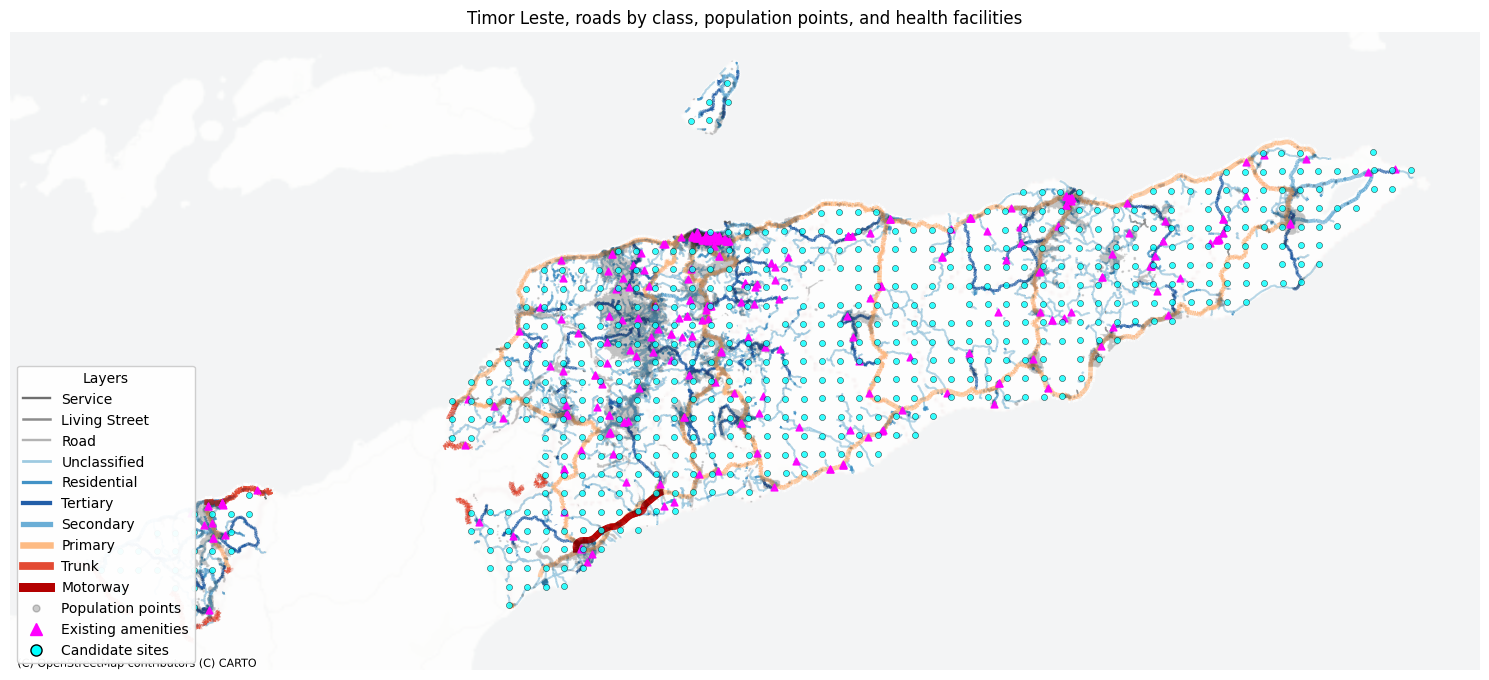

Total plotting time 115.33 seconds


In [13]:
map_facilities = build_map_facilities(
    health_centers=health_centers,
    candidate_sites_snapped=candidate_sites_snapped,
)

context_map_path = build_context_map_path(
    default_path=cache.context_map_path(),
    user_path=settings.context_map_path,
    candidate_grid_spacing_m=cfg.candidate_grid_spacing_m,
)

plot_context_map(
    roads=roads,
    population_points=population_points,
    health_centers=map_facilities,
    title=cfg.PLOT_TITLE,
    output_path=context_map_path if settings.save_context_map else None,
    dpi=settings.context_map_dpi,
    show=settings.show_context_map,
    verbose=settings.verbose,
)

In [14]:
population = cache.run(
    cache_path=cache.population_snapped_path(distance_col='dist_snap_target'),
    builder=lambda: snap_points_to_nodes(
        population_points,
        nodes,
        distance_col='dist_snap_target',
        projected_epsg=cfg.PROJECTED_EPSG,
        verbose=settings.verbose,
    ),
)

population = ensure_id_column(population, prefix='target')
population = ensure_id_index_matches(population)

print(format_shape(population))
population.head()

Loading cache: tls_ppp_2020_population_snapped_dist_snap_target_epsg_32751.pkl
Load time: 0.01s
Total time: 0.02s
252,814 x 8


,ID,Longitude,Latitude,population,row,col,nearest_node,dist_snap_target
ID,,,,,,,,
0,0,125.625833,-8.129166,1.347106,3,1897,4363346648,1316.800184
1,1,125.626666,-8.129166,1.259432,3,1898,4363346648,1231.527979
2,2,125.627500,-8.129166,1.240076,3,1899,4363346648,1147.279412
3,3,125.628333,-8.129166,1.056157,3,1900,4363346648,1064.297618
4,4,125.624166,-8.130000,1.321901,4,1895,4363346648,1462.933449


In [15]:
existing_sources = cache.run(
    cache_path=cache.hospitals_snapped_path(distance_col='dist_snap_source'),
    builder=lambda: snap_points_to_nodes(
        health_centers,
        nodes,
        distance_col='dist_snap_source',
        projected_epsg=cfg.PROJECTED_EPSG,
        verbose=settings.verbose,
    ),
)

print(existing_sources.shape)
existing_sources.head()

existing_sources = existing_sources.copy()
existing_sources['source_type'] = 'existing'

existing_sources = ensure_id_column(existing_sources, prefix='existing')
existing_sources = ensure_id_index_matches(existing_sources)


Loading cache: east-timor-latest.osm_hospitals_snapped_dist_snap_source_epsg_32751.pkl
Load time: 0.00s
Total time: 0.00s
(284, 31)


In [16]:
print(population.dtypes)
print()
print(existing_sources.dtypes)

ID                   object
Longitude           float64
Latitude            float64
population          float64
row                   int32
col                   int32
nearest_node          int64
dist_snap_target    float64
dtype: object

visible              object
timestamp            uint32
lon                 float32
changeset           float64
id                    int64
tags                 object
lat                 float32
version               int32
addr:city            object
addr:full            object
addr:housenumber     object
addr:postcode        object
addr:street          object
email                object
name                 object
opening_hours        object
operator             object
phone                object
amenity              object
building             object
building:levels      object
source               object
osm_type             object
addr:place           object
office               object
Name                 object
ID                   object
Longi

In [17]:
print(population.columns.tolist())
print(existing_sources.columns.tolist())

assert 'Longitude' in population.columns
assert 'Latitude' in population.columns
assert 'Longitude' in existing_sources.columns
assert 'Latitude' in existing_sources.columns

['ID', 'Longitude', 'Latitude', 'population', 'row', 'col', 'nearest_node', 'dist_snap_target']
['visible', 'timestamp', 'lon', 'changeset', 'id', 'tags', 'lat', 'version', 'addr:city', 'addr:full', 'addr:housenumber', 'addr:postcode', 'addr:street', 'email', 'name', 'opening_hours', 'operator', 'phone', 'amenity', 'building', 'building:levels', 'source', 'osm_type', 'addr:place', 'office', 'Name', 'ID', 'Longitude', 'Latitude', 'nearest_node', 'dist_snap_source', 'source_type']


In [18]:
sources_for_matrix = combine_existing_and_candidate_sources(
    facilities=existing_sources,
    candidate_sites_snapped=candidate_sites_snapped,
)

matrix_cache_path = cache.distance_matrix_path(
    distance_threshold_largest=cfg.DISTANCE_THRESHOLD_KM,
    max_total_dist=settings.max_total_dist,
)

if candidate_sites is not None:
    matrix_cache_path = matrix_cache_path.with_stem(f'{matrix_cache_path.stem}_with_candidates')

matrix_df = cache.run(
    cache_path=matrix_cache_path,
    builder=lambda: compute_distances(
        targets=population,
        sources=sources_for_matrix,
        distance_threshold_largest=cfg.DISTANCE_THRESHOLD_KM,
        network=network,
        max_total_dist=settings.max_total_dist,
        verbose=settings.verbose,
    ),
)

print(f'rows: {matrix_df.shape[0]:,}, cols: {matrix_df.shape[1]:,}')
matrix_df.head()


Loading cache: east-timor-latest.osm_distance_matrix_threshold_300km_max_total_none_with_candidates.pkl
Load time: 17.77s
Total time: 17.77s
rows: 166,475,411, cols: 8


,target_id,source_id,source_nearest_node,target_nearest_node,target_to_road_dist,road_distance,source_to_road_dist,total_dist
0,39052,1258106905,262453276,262311498,13.148362,5667.662,25.860703,5706.671065
1,39052,13260719603,262453322,262311498,13.148362,3250.716,34.412154,3298.276516
2,39052,169398199,317722021,262311498,13.148362,2484.874,38.539257,2536.561619
3,39052,169398231,317722021,262311498,13.148362,2484.874,51.709075,2549.731437
4,39052,11601400492,317722031,262311498,13.148362,2457.573,35.451001,2506.172363


In [19]:
with pd.option_context('display.float_format', '{:,.0f}'.format):
    display(matrix_df['total_dist'].describe())

count   166,475,411
mean        136,120
std          75,128
min              24
25%          77,199
50%         127,182
75%         187,083
max         418,211
Name: total_dist, dtype: float64

In [20]:
output_dir = cfg.BASE_DIR / 'outputs'
output_dir.mkdir(parents=True, exist_ok=True)

run_tag = (
    f"pop_{settings.population_threshold:g}_"
    f"sample_{settings.sample_fraction:g}_"
    f"max_{'none' if settings.max_points is None else settings.max_points}_"
    f"maxdist_{'none' if settings.max_total_dist is None else f'{settings.max_total_dist:g}'}"
)

population_path = output_dir / f'population_{run_tag}.parquet'
existing_sources_path = output_dir / f'existing_sources_{run_tag}.parquet'
matrix_path = output_dir / f'distance_matrix_{run_tag}.parquet'

population.to_parquet(population_path, index=False)
existing_sources.to_parquet(existing_sources_path, index=False)
matrix_df.to_parquet(matrix_path, index=False)

print(population_path)
print(existing_sources_path)
print(matrix_path)

C:\local\Download_Depot\east-timor_data\outputs\population_pop_1_sample_1_max_none_maxdist_none.parquet
C:\local\Download_Depot\east-timor_data\outputs\existing_sources_pop_1_sample_1_max_none_maxdist_none.parquet
C:\local\Download_Depot\east-timor_data\outputs\distance_matrix_pop_1_sample_1_max_none_maxdist_none.parquet


In [21]:
matrix_df.columns.tolist()

['target_id',
 'source_id',
 'source_nearest_node',
 'target_nearest_node',
 'target_to_road_dist',
 'road_distance',
 'source_to_road_dist',
 'total_dist']

In [22]:
print(f'Population rows: {len(population):,}')
print(f'Existing source rows: {len(existing_sources):,}')
print(f'Distance rows: {len(matrix_df):,}')

print()
print(f'Unique population ids in matrix: {matrix_df['target_id'].nunique():,}')
print(f'Unique source ids in matrix: {matrix_df['source_id'].nunique():,}')

Population rows: 252,814
Existing source rows: 284
Distance rows: 166,475,411

Unique population ids in matrix: 246,657
Unique source ids in matrix: 822


In [23]:
with pd.option_context('display.float_format', '{:,.2f}'.format):
    display(matrix_df.describe())

,source_nearest_node,target_nearest_node,target_to_road_dist,road_distance,source_to_road_dist,total_dist
count,"166,475,411.00","166,475,411.00","166,475,411.00","166,475,411.00","166,475,411.00","166,475,411.00"
mean,"6,321,158,307.85","6,626,573,724.17",284.88,"135,171.76",663.17,"136,119.81"
std,"3,968,683,095.84","4,032,365,466.87",333.15,"74,953.69",943.35,"75,127.65"
min,"262,453,276.00","262,311,498.00",0.24,0.00,1.19,23.84
25%,"1,814,088,432.00","1,814,088,934.00",76.67,"76,376.97",34.41,"77,198.69"
50%,"6,315,464,009.00","6,842,499,039.00",187.60,"126,169.87",216.15,"127,181.93"
75%,"10,081,816,412.00","10,679,793,272.00",375.83,"186,032.17",963.46,"187,082.79"
max,"13,584,432,389.00","13,718,899,180.00","4,679.59","414,834.17","4,994.56","418,211.25"


In [27]:
dists = {c : matrix_df[c].sum() for c in matrix_df.columns if 'dist' in c}

In [28]:
{
    key: f'{value / dists["total_dist"]:.2%}'
    for key, value in dists.items()
    if key != 'total_dist'
}

{'target_to_road_dist': '0.21%',
 'road_distance': '99.30%',
 'source_to_road_dist': '0.49%'}